# Simulating iceberg statistics

In [1]:
# Import of packages (utils.py) and additional functions (utils.py, simu_late.py)
from src.utils import *
from src.simu_late import *

Openberg can simulate a number of icebergs from different positions, with different size in the same run effciently. We try to use this feature to decrease simulation time. However, we need to loop for varied input and start times.

In [2]:
#What we can simulate in ONE run:

#Iceberg number: from statistics derived from Sentinel'2 counting
n=5 #more liekly on the scale 100-900 for the statistics
#Randomised position: within radius around coordinates
lons,lats,radii = 37.81915,80.5794,100
#Randomised size: drawing length (and width) from size distribution, rest will be calculated from empirical relations automatically (function src/simu_late.py:calc_iceberg_size())
randspace=np.random.rand(n)
lengths, widths = randspace*(10)+100, randspace**(10)+80 #ADAPT. This is a placeholder. Replace with proper drawing from a distribution.
#Randomised time: 
times=datetime(2022,6,1)
dict_in = {'simulationname':'topaz4_era5',
           'config':{'seed:wind_form_drag_coef':1.5, 'seed:water_form_drag_coef':1.5},#the model default configurations are as recommended otherwise
           'input':['cmems_mod_arc_phy_my_topaz4_P1D-m',
                  #{'era5':{'ref':'../input/era5_2023_09_10-18.nc'}}
                   ],
           'seed':
           {'number': n,  
            'lon': lons, 'lat': lats,'radius':radii, #Position
            'length': lengths, 'width': widths,  #Size
           'time': times}, #Time
           'run':{#'duration':timedelta(days=10), #ADAPT LATER
                'loglevel':50,
                'logfile':True,
                'time_step':timedelta(days=1)}#ADAPT to 1hour
          }

o1 = simu_late(dict_in) 

Input used:  ['cmems_mod_arc_phy_my_topaz4_P1D-m']
{'cmems_mod_arc_phy_my_topaz4_P1D-m': {'ref': 'cmems_mod_arc_phy_my_topaz4_P1D-m'}}


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 28.12it/s]
INFO - 2026-04-24T15:16:19Z - Selected dataset version: "202506"
INFO - 2026-04-24T15:16:19Z - Selected dataset part: "default"


initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial timestep velocity from ci>15%
initial time

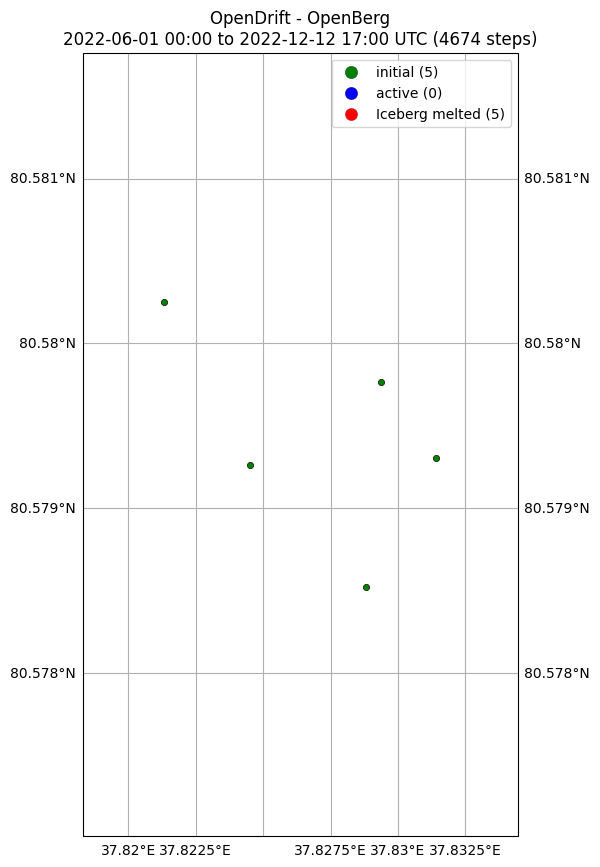

(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2022-06-01 00:00 to 2022-12-12 17:00 UTC (4674 steps)'}>,
 <Figure size 610.375x1100 with 1 Axes>)

In [3]:
o1.plot(fast=True)